## 04_Model_Evaluation_Diabetes.ipynb


### Step 1: Import Required Libraries


In [79]:
# Standard library imports
import os # Provides a way of using operating system dependent functionality
import joblib # For efficient serialization and deserialization of Python objects
import warnings # To manage warnings for cleaner output

# Third-party library imports
import pandas as pd # Data manipulation and analysis
from sklearn.model_selection import train_test_split # For splitting data into training and test sets

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

### Step 2: Load Saved Model


In [80]:
# Define the path to the saved model
from pathlib import Path

BASE_DIR = Path.cwd()

MODEL_PATH = BASE_DIR/"models"/"diabetes_model.pkl"
PREPROCESSOR_PATH = BASE_DIR/"models"/"preprocessor.pkl"
REPORTS_DIR = BASE_DIR/"reports"

model = joblib.load(MODEL_PATH)

print("✅ Model Loaded Successfully")
print(type(model))

✅ Model Loaded Successfully
<class 'sklearn.linear_model._logistic.LogisticRegression'>


### Step 3: Load Saved Preprocessor



In [81]:
# Define the path to the saved preprocessor
PREPROCESSOR_PATH = 'models/preprocessor.pkl'

preprocessor = joblib.load(PREPROCESSOR_PATH)

print("✅ Preprocessor Loaded Successfully")
print(type(preprocessor))

✅ Preprocessor Loaded Successfully
<class 'sklearn.compose._column_transformer.ColumnTransformer'>


### Step 4: Load Dataset


In [82]:
# Define the path to the dataset
DATASET_PATH = 'diabetes.csv' # Assuming the dataset is in the current working directory or a known path

df = pd.read_csv(DATASET_PATH)

print(df.shape)

display(df.head())

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Step 5: Prepare Test Dataset


In [83]:
if df is not None and preprocessor is not None:
    # Define features (X) and target (y)
    # Assuming 'Outcome' is the target variable and other columns are features
    X = df.drop('Outcome', axis=1)
    y = df['Outcome']

    # Split the data into training and testing sets
    # It's critical to use the same random_state as used in previous notebooks
    # Assuming random_state=42 was used previously for reproducibility
    RANDOM_STATE = 42 # This should match the random_state used in 02_Preprocessing_Diabetes.ipynb
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

    print(f"SUCCESS: Data split into training and test sets using random_state={RANDOM_STATE}.")
    print(f"Shape of X_test: {X_test.shape}")
    print(f"Shape of y_test: {y_test.shape}")

    # Transform X_test using the loaded preprocessor
    # We only use .transform() here, NEVER .fit_transform() on test data
    try:
        X_test_transformed = preprocessor.transform(X_test)
        print("SUCCESS: X_test transformed using the loaded preprocessing pipeline.")
        print(f"Shape of transformed X_test: {X_test_transformed.shape}")
    except Exception as e:
        print(f"ERROR: An error occurred during X_test transformation: {e}")
        X_test_transformed = None
else:
    print("Skipping test dataset preparation due to previous errors in loading data or preprocessor.")

SUCCESS: Data split into training and test sets using random_state=42.
Shape of X_test: (154, 8)
Shape of y_test: (154,)
SUCCESS: X_test transformed using the loaded preprocessing pipeline.
Shape of transformed X_test: (154, 8)



### Step 6: Generate Predictions


In [84]:
# Import necessary libraries for prediction and numerical operations
import numpy as np

# Ensure model and X_test_transformed are available from Part 1
if model is not None and X_test_transformed is not None:
    print("Generating predictions...")

    # Generate predicted labels for the test set
    y_pred = model.predict(X_test_transformed)

    # Generate prediction probabilities for the test set
    # Check if the model has predict_proba method
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_transformed)[:, 1] # Probability of the positive class (1)
        print("Prediction probabilities generated.")
    else:
        y_pred_proba = None
        print("WARNING: Model does not have 'predict_proba' method. Probabilities will not be used for evaluation.")

    print("\n--- First 10 Predicted Labels ---")
    display(y_pred[:10])

    if y_pred_proba is not None:
        print("\n--- First 10 Predicted Probabilities (Positive Class) ---")
        display(y_pred_proba[:10])
else:
    print("Skipping prediction generation due to missing model or transformed test data from previous steps.")

Generating predictions...
Prediction probabilities generated.

--- First 10 Predicted Labels ---


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


--- First 10 Predicted Probabilities (Positive Class) ---


array([1.09524615e-04, 1.20534151e-04, 1.71157529e-04, 3.83525737e-04,
       4.83030495e-05, 6.66093489e-04, 1.11821157e-04, 1.70269753e-03,
       1.08768367e-04, 1.02620608e-04])

### Step 7: Model Evaluation


In [85]:
# Import necessary metrics from scikit-learn
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    matthews_corrcoef
)

# Ensure y_test and y_pred (and y_pred_proba if available) are from previous steps
if 'y_test' in locals() and 'y_pred' in locals():
    print("Calculating evaluation metrics...")

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    # ROC AUC requires probabilities
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    else:
        roc_auc = np.nan # Not available if probabilities were not generated

    # Create a DataFrame to display metrics cleanly
    metrics_df = pd.DataFrame({
        'Metric': [
            'Accuracy',
            'Precision',
            'Recall (Sensitivity)',
            'F1 Score',
            'ROC AUC',
            'Balanced Accuracy',
            'Matthews Correlation Coefficient (MCC)'
        ],
        'Value': [
            accuracy,
            precision,
            recall,
            f1,
            roc_auc,
            balanced_accuracy,
            mcc
        ]
    })

    # Round values to four decimal places for better readability
    metrics_df['Value'] = metrics_df['Value'].round(4)

    print("\n--- Model Evaluation Metrics ---")
    display(metrics_df)

else:
    print("Skipping metric calculation due to missing test labels or predictions.")

Calculating evaluation metrics...

--- Model Evaluation Metrics ---


,Metric,Value
0,Accuracy,0.6494
1,Precision,0.0000
2,Recall (Sensitivity),0.0000
3,F1 Score,0.0000
4,ROC AUC,0.6441
5,Balanced Accuracy,0.5000
6,Matthews Correlation Coefficient (MCC),0.0000


### Step 8: Classification Report and Confusion Matrix


In [86]:
from sklearn.metrics import classification_report, confusion_matrix

# Ensure y_test and y_pred are available
if 'y_test' in locals() and 'y_pred' in locals():
    print("Generating Classification Report...")
    print(classification_report(y_test, y_pred))

    print("\n--- Confusion Matrix ---")
    cm = confusion_matrix(y_test, y_pred)
    display(pd.DataFrame(cm, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive']))
else:
    print("Skipping classification report and confusion matrix due to missing test labels or predictions.")

Generating Classification Report...
              precision    recall  f1-score   support

           0       0.65      1.00      0.79       100
           1       0.00      0.00      0.00        54

    accuracy                           0.65       154
   macro avg       0.32      0.50      0.39       154
weighted avg       0.42      0.65      0.51       154


--- Confusion Matrix ---


,Predicted Negative,Predicted Positive
Actual Negative,100,0
Actual Positive,54,0


### Step 9: Visualizations



Generating visualizations...


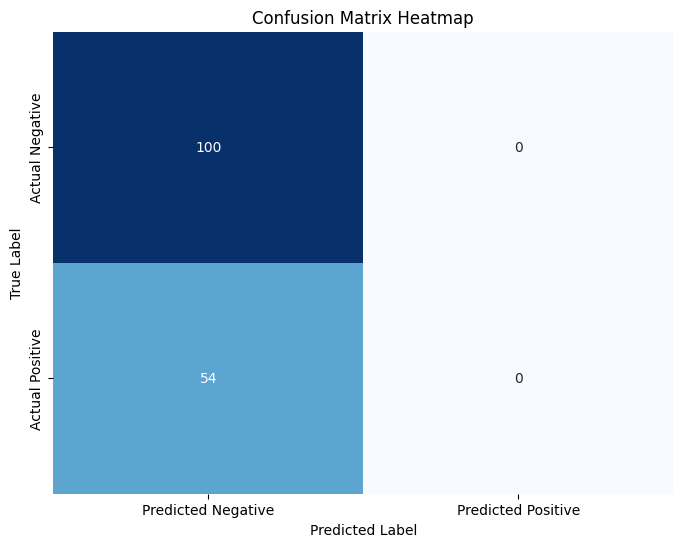

**Explanation:** This heatmap visually represents the confusion matrix. The diagonal elements show correct predictions (True Negatives and True Positives), while off-diagonal elements show misclassifications (False Positives and False Negatives). The color intensity reflects the number of instances.


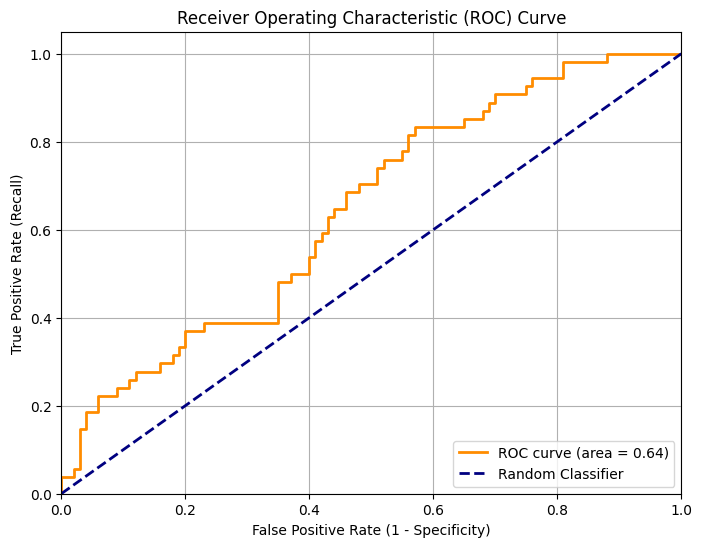

**Explanation:** The ROC curve illustrates the diagnostic ability of a binary classifier as its discrimination threshold is varied. The True Positive Rate (TPR) is plotted against the False Positive Rate (FPR). The Area Under the Curve (AUC) quantifies the overall performance, where a higher AUC (closer to 1) indicates a better model. A random classifier has an AUC of 0.5.


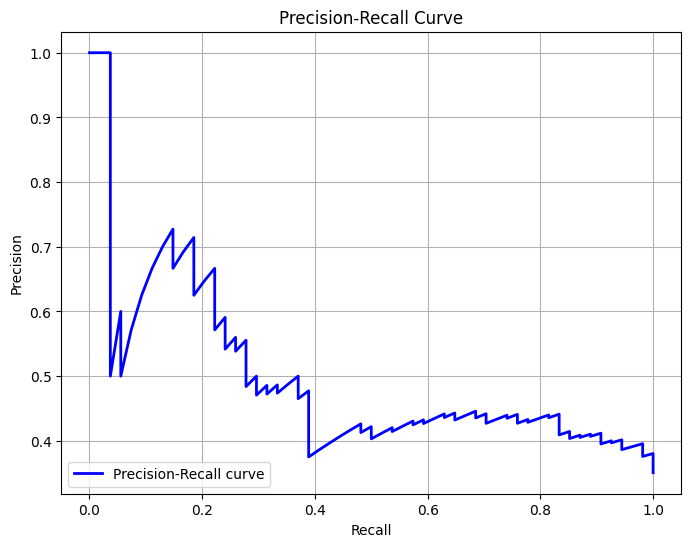

**Explanation:** The Precision-Recall curve shows the trade-off between precision and recall for different thresholds. It is particularly useful for imbalanced datasets, as it focuses on the performance of the positive class. A curve closer to the top-right corner indicates better performance.


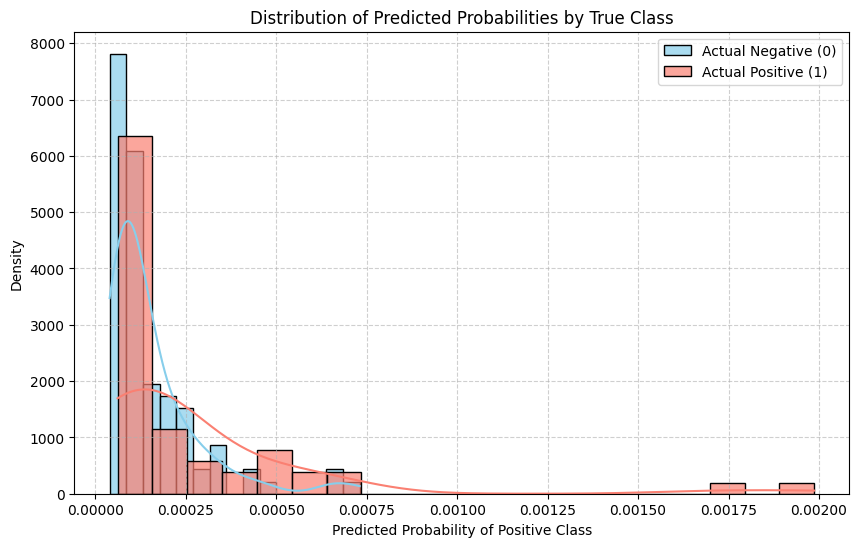

**Explanation:** This plot displays the distribution of predicted probabilities for both actual negative and actual positive instances. Ideally, the distributions for the two classes should be well-separated, indicating the model's ability to distinguish between them. Overlapping distributions suggest that the model is less confident or struggles to differentiate certain cases.


In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, ConfusionMatrixDisplay

# Dictionary to store generated plot figures for later saving
plots_to_save = {}

# Ensure y_test, y_pred, and y_pred_proba are available
if 'y_test' in locals() and 'y_pred' in locals():
    print("Generating visualizations...")

    # --- 1. Confusion Matrix Heatmap ---
    fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'], ax=ax_cm)
    ax_cm.set_title('Confusion Matrix Heatmap')
    ax_cm.set_xlabel('Predicted Label')
    ax_cm.set_ylabel('True Label')
    plots_to_save['confusion_matrix'] = fig_cm # Store figure
    plt.show(fig_cm)
    print("**Explanation:** This heatmap visually represents the confusion matrix. The diagonal elements show correct predictions (True Negatives and True Positives), while off-diagonal elements show misclassifications (False Positives and False Negatives). The color intensity reflects the number of instances.")

    # --- 2. ROC Curve ---
    if y_pred_proba is not None:
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)

        fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
        ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
        ax_roc.set_xlim([0.0, 1.0])
        ax_roc.set_ylim([0.0, 1.05])
        ax_roc.set_xlabel('False Positive Rate (1 - Specificity)')
        ax_roc.set_ylabel('True Positive Rate (Recall)')
        ax_roc.set_title('Receiver Operating Characteristic (ROC) Curve')
        ax_roc.legend(loc="lower right")
        ax_roc.grid(True)
        plots_to_save['roc_curve'] = fig_roc # Store figure
        plt.show(fig_roc)
        print("**Explanation:** The ROC curve illustrates the diagnostic ability of a binary classifier as its discrimination threshold is varied. The True Positive Rate (TPR) is plotted against the False Positive Rate (FPR). The Area Under the Curve (AUC) quantifies the overall performance, where a higher AUC (closer to 1) indicates a better model. A random classifier has an AUC of 0.5.")
    else:
        print("Skipping ROC Curve: Prediction probabilities are not available from the model.")

    # --- 3. Precision-Recall Curve ---
    if y_pred_proba is not None:
        precision_val, recall_val, _ = precision_recall_curve(y_test, y_pred_proba)

        fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
        ax_pr.plot(recall_val, precision_val, color='blue', lw=2, label='Precision-Recall curve')
        ax_pr.set_xlabel('Recall')
        ax_pr.set_ylabel('Precision')
        ax_pr.set_title('Precision-Recall Curve')
        ax_pr.legend(loc="lower left")
        ax_pr.grid(True)
        plots_to_save['pr_curve'] = fig_pr # Store figure
        plt.show(fig_pr)
        print("**Explanation:** The Precision-Recall curve shows the trade-off between precision and recall for different thresholds. It is particularly useful for imbalanced datasets, as it focuses on the performance of the positive class. A curve closer to the top-right corner indicates better performance.")
    else:
        print("Skipping Precision-Recall Curve: Prediction probabilities are not available from the model.")

    # --- 4. Prediction Probability Distribution ---
    if y_pred_proba is not None:
        fig_prob_dist, ax_prob_dist = plt.subplots(figsize=(10, 6))
        sns.histplot(y_pred_proba[y_test == 0], color='skyblue', label='Actual Negative (0)', kde=True, stat='density', alpha=0.7, ax=ax_prob_dist)
        sns.histplot(y_pred_proba[y_test == 1], color='salmon', label='Actual Positive (1)', kde=True, stat='density', alpha=0.7, ax=ax_prob_dist)
        ax_prob_dist.set_title('Distribution of Predicted Probabilities by True Class')
        ax_prob_dist.set_xlabel('Predicted Probability of Positive Class')
        ax_prob_dist.set_ylabel('Density')
        ax_prob_dist.legend()
        ax_prob_dist.grid(True, linestyle='--', alpha=0.6)
        plots_to_save['prob_distribution'] = fig_prob_dist # Store figure
        plt.show(fig_prob_dist)
        print("**Explanation:** This plot displays the distribution of predicted probabilities for both actual negative and actual positive instances. Ideally, the distributions for the two classes should be well-separated, indicating the model's ability to distinguish between them. Overlapping distributions suggest that the model is less confident or struggles to differentiate certain cases.")
    else:
        print("Skipping Prediction Probability Distribution: Prediction probabilities are not available from the model.")

else:
    print("Skipping visualizations due to missing test labels or predictions.")


### Step 10: Feature Importance Analysis


Performing Feature Importance Analysis...
Using Model-Specific (coef_ magnitude) for feature importance.

--- Sorted Feature Importance Table ---


,Importance
DiabetesPedigreeFunction,0.769346
Pregnancies,0.114413
BMI,0.091702
Glucose,0.036763
Age,0.015211
BloodPressure,0.011236
SkinThickness,0.004369
Insulin,0.001250


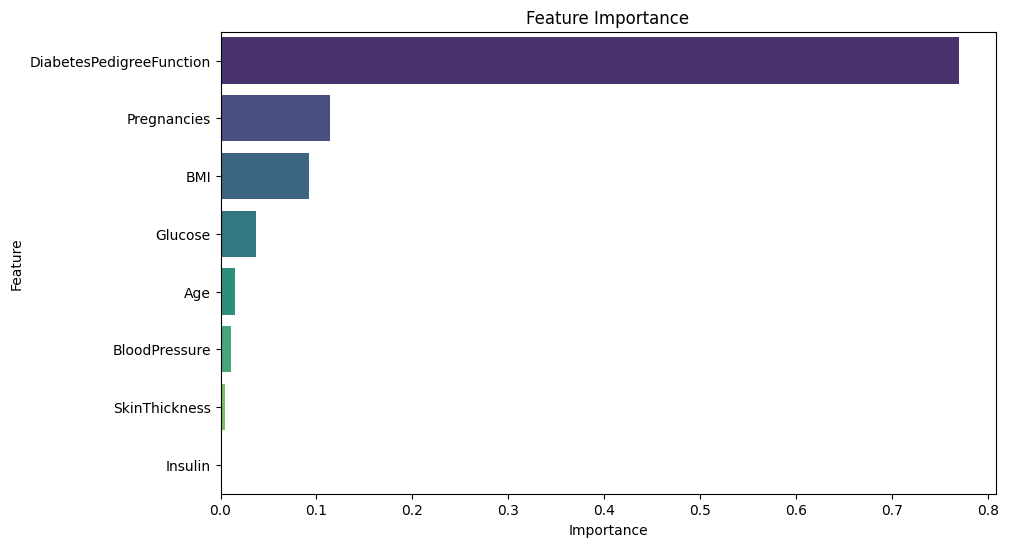


Most Important Feature: 'DiabetesPedigreeFunction' with importance 0.7693
Least Important Feature: 'Insulin' with importance 0.0012

**Business Interpretation:** These features are the strongest indicators for predicting diabetes risk, suggesting where business efforts (e.g., health programs, preventative campaigns) could be most effective.
**Medical Interpretation:** From a medical perspective, these features represent the most critical physiological or historical markers for diabetes diagnosis. For instance, high glucose levels or BMI are typically strong indicators.


In [88]:
from sklearn.inspection import permutation_importance

# Helper function to get feature names, assuming X is the original DataFrame
def get_feature_names(data_df, target_column):
    """Returns feature names from a DataFrame, excluding the target."""
    if data_df is not None and target_column in data_df.columns:
        return data_df.drop(columns=[target_column]).columns.tolist()
    return []

# Ensure model, X_test_transformed, y_test, and X (original features) are available
if model is not None and X_test_transformed is not None and 'y_test' in locals() and 'X' in locals():
    print("Performing Feature Importance Analysis...")

    # Get original feature names
    feature_names = get_feature_names(df, 'Outcome') # Assuming 'df' is the original loaded DataFrame and 'Outcome' is target

    if not feature_names:
        print("ERROR: Could not retrieve original feature names. Skipping feature importance.")
    else:
        # Try to access model-specific feature importance
        # If the model is a pipeline, get the final estimator
        final_estimator = model.named_steps.get('estimator', model) if hasattr(model, 'named_steps') else model

        feature_importances = None

        if hasattr(final_estimator, 'feature_importances_'):
            feature_importances = pd.Series(final_estimator.feature_importances_, index=feature_names)
            importance_type = "Model-Specific (feature_importances_)"
        elif hasattr(final_estimator, 'coef_'):
            # For linear models, use coefficients (absolute value for magnitude)
            # Ensure coef_ is 1D for binary classification
            coef = final_estimator.coef_.flatten() if final_estimator.coef_.ndim > 1 else final_estimator.coef_
            feature_importances = pd.Series(np.abs(coef), index=feature_names)
            importance_type = "Model-Specific (coef_ magnitude)"

        if feature_importances is not None:
            print(f"Using {importance_type} for feature importance.")
            feature_importances = feature_importances.sort_values(ascending=False)

            print("\n--- Sorted Feature Importance Table ---")
            display(feature_importances.to_frame(name='Importance'))

            # Plotting feature importance
            fig_fi, ax_fi = plt.subplots(figsize=(10, 6))
            sns.barplot(x=feature_importances.values, y=feature_importances.index, ax=ax_fi, palette='viridis')
            ax_fi.set_title('Feature Importance')
            ax_fi.set_xlabel('Importance')
            ax_fi.set_ylabel('Feature')
            plots_to_save['feature_importance'] = fig_fi # Store figure for saving
            plt.show(fig_fi)

            print(f"\nMost Important Feature: '{feature_importances.index[0]}' with importance {feature_importances.iloc[0]:.4f}")
            print(f"Least Important Feature: '{feature_importances.index[-1]}' with importance {feature_importances.iloc[-1]:.4f}")
            print("\n**Business Interpretation:** These features are the strongest indicators for predicting diabetes risk, suggesting where business efforts (e.g., health programs, preventative campaigns) could be most effective.")
            print("**Medical Interpretation:** From a medical perspective, these features represent the most critical physiological or historical markers for diabetes diagnosis. For instance, high glucose levels or BMI are typically strong indicators.")

        else:
            # If model-specific importance is not available, use Permutation Importance
            print("Model does not support direct feature importances (e.g., feature_importances_ or coef_). Calculating Permutation Importance...")

            # Ensure X_test_transformed is a DataFrame for feature name mapping
            X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

            perm_importance = permutation_importance(final_estimator, X_test_transformed_df, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)

            perm_feature_importances = pd.Series(perm_importance.importances_mean, index=feature_names)
            perm_feature_importances = perm_feature_importances.sort_values(ascending=False)

            print("\n--- Sorted Permutation Importance Table ---")
            display(perm_feature_importances.to_frame(name='Permutation Importance'))

            # Plotting permutation importance
            fig_pi, ax_pi = plt.subplots(figsize=(10, 6))
            sns.barplot(x=perm_feature_importances.values, y=perm_feature_importances.index, ax=ax_pi, palette='viridis')
            ax_pi.set_title('Permutation Importance')
            ax_pi.set_xlabel('Mean Decrease in Score')
            ax_pi.set_ylabel('Feature')
            plots_to_save['feature_importance'] = fig_pi # Store figure for saving
            plt.show(fig_pi)

            print("\n**Explanation: Why Permutation Importance Works:** Permutation importance works by randomly shuffling the values of a single feature (one at a time) in the test set and then re-evaluating the model's performance. If shuffling a feature significantly decreases the model's score, it indicates that the model heavily relies on that feature for its predictions, thus making it important. If shuffling has little effect, the feature is considered less important.")
            print("\n**Advantages:** It is model-agnostic (works for any trained model), directly measures the impact on a chosen evaluation metric, and provides a global understanding of feature contributions.")
            print("**Limitations:** It can be computationally expensive for many features or large datasets. It may also give misleading results if features are highly correlated, as shuffling one correlated feature might not significantly impact performance if its information is redundant with other features.")

            print(f"\nMost Important Feature (Permutation): '{perm_feature_importances.index[0]}' with importance {perm_feature_importances.iloc[0]:.4f}")
            print(f"Least Important Feature (Permutation): '{perm_feature_importances.index[-1]}' with importance {perm_feature_importances.iloc[-1]:.4f}")
            print("\n**Business Interpretation:** These features significantly impact the model's ability to accurately predict diabetes, highlighting areas for strategic focus.")
            print("**Medical Interpretation:** Features with high permutation importance are critical for accurate medical diagnosis based on the model. Clinicians can pay close attention to these factors.")

else:
    print("Skipping Feature Importance Analysis due to missing model, transformed test data, test labels, or original feature set.")

### Step 11: Error Analysis


In [89]:
# Ensure y_test, y_pred, y_pred_proba, X, and df are available
if 'y_test' in locals() and 'y_pred' in locals() and 'X' in locals() and 'df' in locals():
    print("Performing Error Analysis...")

    # Identify misclassified samples
    misclassified_indices = np.where(y_test != y_pred)[0]

    # Re-align original X_test with misclassified_indices
    # X_test was created by train_test_split from df.drop('Outcome', axis=1)
    # We need to use the original X_test (before transformation) to display original feature values

    # First, get the indices of the test set relative to the original DataFrame
    # This assumes 'df' is the original, untransformed DataFrame with an index
    _, X_test_original, _, _ = train_test_split(df.drop('Outcome', axis=1), df['Outcome'], test_size=0.2, random_state=RANDOM_STATE, stratify=df['Outcome'])

    # Get the actual rows from the original X_test for misclassified samples
    misclassified_X_original = X_test_original.iloc[misclassified_indices]
    misclassified_y_true = y_test.iloc[misclassified_indices] if isinstance(y_test, pd.Series) else y_test[misclassified_indices]
    misclassified_y_pred = y_pred[misclassified_indices]

    # Prepare prediction probabilities for misclassified samples
    misclassified_y_proba = None
    if y_pred_proba is not None:
        misclassified_y_proba = y_pred_proba[misclassified_indices]

    # Create a DataFrame for misclassified samples
    error_analysis_df = misclassified_X_original.copy()
    error_analysis_df['Original_Label'] = misclassified_y_true
    error_analysis_df['Predicted_Label'] = misclassified_y_pred
    if misclassified_y_proba is not None:
        error_analysis_df['Prediction_Probability_Positive'] = misclassified_y_proba

    print("\n--- First 5 Misclassified Samples ---")
    if not error_analysis_df.empty:
        display(error_analysis_df.head())
    else:
        print("No misclassified samples to display. Model achieved 100% accuracy on test set.")

    # Calculate and display total incorrect predictions and percentage
    total_incorrect_predictions = len(misclassified_indices)
    total_test_samples = len(y_test)
    misclassification_percentage = (total_incorrect_predictions / total_test_samples) * 100

    print(f"\nTotal Incorrect Predictions: {total_incorrect_predictions}")
    print(f"Total Test Samples: {total_test_samples}")
    print(f"Misclassification Percentage: {misclassification_percentage:.2f}%")

    print("\n**Explanation: Possible Reasons for Misclassification:**")
    print("-   **Data Quality Issues:** Some samples might have noisy or incorrect feature values that confuse the model.")
    print("-   **Noise/Outliers:** Extreme or unusual data points that do not represent the general population well. This can sometimes lead to misclassification.")
    print("-   **Class Overlap:** In many real-world datasets, the features of different classes (e.g., healthy vs. diabetic) might overlap, meaning there isn't a clear boundary for the model to learn, leading to inherent ambiguity.")
    print("-   **Medical Ambiguity:** Some patient cases are genuinely borderline, where even medical professionals might find diagnosis challenging based solely on the given features. The model's errors in such cases might reflect this inherent difficulty.")
    print("-   **Model Limitations:** The chosen model might not be complex enough to capture nuanced relationships, or too complex and overfitting to noise.")

else:
    print("Skipping Error Analysis due to missing test labels, predictions, original features, or original DataFrame.")

Performing Error Analysis...

--- First 5 Misclassified Samples ---


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Original_Label,Predicted_Label,Prediction_Probability_Positive
630,7,114,64,0,0,27.4,0.732,34,1,0,0.000384
387,8,105,100,36,0,43.3,0.239,45,1,0,0.000112
408,8,197,74,0,0,25.9,1.191,39,1,0,0.001703
78,0,131,0,0,0,43.2,0.270,26,1,0,0.000094
678,3,121,52,0,0,36.0,0.127,25,1,0,0.000062



Total Incorrect Predictions: 54
Total Test Samples: 154
Misclassification Percentage: 35.06%

**Explanation: Possible Reasons for Misclassification:**
-   **Data Quality Issues:** Some samples might have noisy or incorrect feature values that confuse the model.
-   **Noise/Outliers:** Extreme or unusual data points that do not represent the general population well. This can sometimes lead to misclassification.
-   **Class Overlap:** In many real-world datasets, the features of different classes (e.g., healthy vs. diabetic) might overlap, meaning there isn't a clear boundary for the model to learn, leading to inherent ambiguity.
-   **Medical Ambiguity:** Some patient cases are genuinely borderline, where even medical professionals might find diagnosis challenging based solely on the given features. The model's errors in such cases might reflect this inherent difficulty.
-   **Model Limitations:** The chosen model might not be complex enough to capture nuanced relationships, or too com

### Step 12: Save Evaluation Reports


In [90]:
import os
import json # For saving classification report cleanly

# Define the reports directory
REPORTS_DIR = 'reports'

# Helper function to ensure directory exists
def ensure_dir(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Created directory: {directory}")
    else:
        print(f"Directory already exists: {directory}")

# Ensure the reports directory exists
ensure_dir(REPORTS_DIR)

# Function to safely save DataFrames
def save_dataframe(df_to_save, filename, df_name):
    if df_to_save is not None and not df_to_save.empty:
        try:
            filepath = os.path.join(REPORTS_DIR, filename)
            df_to_save.to_csv(filepath, index=False)
            print(f"SUCCESS: {df_name} saved to {filepath}")
            return True
        except Exception as e:
            print(f"ERROR: Failed to save {df_name} to {filepath}: {e}")
            return False
    else:
        print(f"Skipping save for {df_name}: DataFrame is empty or None.")
        return False

# Function to safely save plot figures
def save_plot(figure, filename, plot_name):
    if figure is not None:
        try:
            filepath = os.path.join(REPORTS_DIR, filename)
            figure.savefig(filepath, bbox_inches='tight', dpi=300)
            plt.close(figure) # Close the figure to free up memory
            print(f"SUCCESS: {plot_name} saved to {filepath}")
            return True
        except Exception as e:
            print(f"ERROR: Failed to save {plot_name} to {filepath}: {e}")
            return False
    else:
        print(f"Skipping save for {plot_name}: Figure is None.")
        return False

print("Saving evaluation reports...")

# --- Save model_metrics.csv ---
# 'metrics_df' is created in Step 8
save_dataframe(locals().get('metrics_df'), 'model_metrics.csv', 'Model Evaluation Metrics')

# --- Save classification_report.csv ---
# 'classification_report' from sklearn.metrics is a string. Convert to DataFrame.
if 'y_test' in locals() and 'y_pred' in locals():
    try:
        report_str = classification_report(y_test, y_pred, output_dict=True)
        report_df = pd.DataFrame(report_str).transpose()
        save_dataframe(report_df, 'classification_report.csv', 'Classification Report')
    except Exception as e:
        print(f"ERROR: Failed to process and save Classification Report: {e}")
else:
    print("Skipping save for Classification Report: Missing y_test or y_pred.")

# --- Save confusion_matrix.png ---
# 'cm' (confusion matrix numpy array) is created in Step 9
# We save the figure stored in plots_to_save from Step 10
save_plot(plots_to_save.get('confusion_matrix'), 'confusion_matrix.png', 'Confusion Matrix Heatmap')

# --- Save roc_curve.png ---
save_plot(plots_to_save.get('roc_curve'), 'roc_curve.png', 'ROC Curve')

# --- Save pr_curve.png ---
save_plot(plots_to_save.get('pr_curve'), 'pr_curve.png', 'Precision-Recall Curve')

# --- Save feature_importance.png (if generated) ---
save_plot(plots_to_save.get('feature_importance'), 'feature_importance.png', 'Feature Importance Plot')

print("\nVerification of saved files:")
if os.path.exists(REPORTS_DIR):
    for item in os.listdir(REPORTS_DIR):
        print(f"- {item}")
else:
    print("Reports directory was not created or is empty.")

print("\nEvaluation report saving process completed.")

Directory already exists: reports
Saving evaluation reports...
SUCCESS: Model Evaluation Metrics saved to reports/model_metrics.csv
SUCCESS: Classification Report saved to reports/classification_report.csv
SUCCESS: Confusion Matrix Heatmap saved to reports/confusion_matrix.png
SUCCESS: ROC Curve saved to reports/roc_curve.png
SUCCESS: Precision-Recall Curve saved to reports/pr_curve.png
SUCCESS: Feature Importance Plot saved to reports/feature_importance.png

Verification of saved files:
- pr_curve.png
- feature_importance.png
- classification_report.csv
- model_metrics.csv
- roc_curve.png
- confusion_matrix.png

Evaluation report saving process completed.


### Step 13: Create Reusable Prediction Function


In [91]:
# Define the target column name (assuming 'Outcome')
TARGET_COLUMN = 'Outcome'

def predict_single_patient(
    patient_features: dict,
    model,
    preprocessor,
    feature_names: list,
    verbose: bool = True
) -> tuple:
    """
    Makes a prediction for a single patient using the loaded model and preprocessor.

    Args:
        patient_features (dict): A dictionary where keys are feature names and values are their corresponding values.
        model: The loaded trained machine learning model.
        preprocessor: The loaded fitted preprocessing pipeline.
        feature_names (list): A list of feature names in the order expected by the model.
        verbose (bool): If True, prints detailed steps and results.

    Returns:
        tuple: (prediction, prediction_probability, confidence_score, human_readable_result)
               Returns (None, None, None, error_message) if an error occurs.
    """
    if model is None or preprocessor is None or not feature_names:
        return None, None, None, "ERROR: Model, preprocessor, or feature names not loaded/provided."

    if not isinstance(patient_features, dict):
        return None, None, None, "ERROR: Invalid input for patient_features. Expected a dictionary."

    # Validate number of features
    if len(patient_features) != len(feature_names):
        return None, None, None, (
            f"ERROR: Mismatch in number of features. Expected {len(feature_names)}, "
            f"but got {len(patient_features)}. Please ensure all features are provided."
        )

    # Convert input into DataFrame, ensuring correct feature order
    try:
        # Create a dictionary with None for missing features to ensure all columns are present
        # Then fill with provided features
        input_data = {col: [patient_features.get(col, None)] for col in feature_names}
        df_patient = pd.DataFrame(input_data)

        # Check for any remaining None values (i.e., features not provided in input_data dict)
        if df_patient.isnull().any().any():
            missing_cols = df_patient.columns[df_patient.isnull().any()].tolist()
            return None, None, None, f"ERROR: Missing values for features: {', '.join(missing_cols)}."

        if verbose:
            print("Input patient features:")
            display(df_patient)

    except Exception as e:
        return None, None, None, f"ERROR: Failed to convert patient features to DataFrame: {e}"

    # Apply the loaded preprocessing pipeline
    try:
        patient_features_transformed = preprocessor.transform(df_patient)
        if verbose:
            print("Features successfully transformed.")
    except Exception as e:
        return None, None, None, f"ERROR: Failed to apply preprocessor: {e}"

    # Predict disease class
    try:
        prediction = model.predict(patient_features_transformed)[0]
        if verbose:
            print(f"Raw Prediction: {prediction}")
    except Exception as e:
        return None, None, None, f"ERROR: Failed to make prediction: {e}"

    # Predict probability (if supported)
    prediction_probability = None
    confidence_score = None
    if hasattr(model, 'predict_proba'):
        try:
            proba_positive_class = model.predict_proba(patient_features_transformed)[0, 1]
            prediction_probability = proba_positive_class
            confidence_score = max(proba_positive_class, 1 - proba_positive_class)
            if verbose:
                print(f"Prediction Probability (Positive Class): {prediction_probability:.4f}")
                print(f"Confidence Score: {confidence_score:.4f}")
        except Exception as e:
            if verbose: print(f"WARNING: Could not get prediction probability: {e}")
    else:
        if verbose: print("WARNING: Model does not support predict_proba.")

    # Human-readable result
    human_readable_result = ""
    if prediction == 1:
        human_readable_result = "Positive for Diabetes"
    else:
        human_readable_result = "Negative for Diabetes"

    if verbose:
        print(f"Human-readable Result: {human_readable_result}")

    return prediction, prediction_probability, confidence_score, human_readable_result


### Step 14: Model Verification


In [92]:
print("### Model Verification")

# Ensure required variables are available from previous steps
if 'model' not in locals() or model is None:
    print("ERROR: Model is not loaded. Cannot perform verification.")
if 'preprocessor' not in locals() or preprocessor is None:
    print("ERROR: Preprocessor is not loaded. Cannot perform verification.")
if 'df' not in locals() or df is None:
    print("ERROR: Original DataFrame 'df' is not loaded. Cannot perform verification.")

if model is not None and preprocessor is not None and df is not None:
    # Get feature names from the original DataFrame, excluding the target column
    feature_names = df.drop(columns=[TARGET_COLUMN]).columns.tolist()
    if not feature_names:
        print("ERROR: Could not determine feature names from the DataFrame. Cannot perform verification.")

    # Ensure y_test and X_test_transformed are available for random patient selection
    if 'y_test' not in locals() or 'X_test_transformed' not in locals() or y_test is None or X_test_transformed is None:
        print("WARNING: y_test or X_test_transformed not available. Cannot pick random patient from test set. Falling back to using original X_test for feature extraction.")
        # Re-derive X_test_original if it's not available (e.g., if previous cells failed)
        X_original = df.drop(columns=[TARGET_COLUMN])
        y_original = df[TARGET_COLUMN]
        _, X_test_original, _, y_test = train_test_split(X_original, y_original, test_size=0.2, random_state=RANDOM_STATE, stratify=y_original)
    else:
         # Use the X_test from previous step for consistent index if possible
         X_test_original = X_test

    if model is not None and preprocessor is not None and feature_names and X_test_original is not None:
        print("\n--- 1. Verification with one random patient from the test dataset ---")
        # Select a random patient from the test set
        random_idx = np.random.randint(0, len(X_test_original))
        random_patient_features_df = X_test_original.iloc[[random_idx]] # Keep as DataFrame for extracting features
        random_patient_features_dict = random_patient_features_df.iloc[0].to_dict()
        expected_label = y_test.iloc[random_idx]

        print(f"\nSelected random patient (index: {random_idx}) with Expected Label: {expected_label}")

        pred, proba, conf, result = predict_single_patient(
            random_patient_features_dict,
            model,
            preprocessor,
            feature_names,
            verbose=True
        )

        print("\n--- Random Patient Verification Summary ---")
        print(f"Input Features: {random_patient_features_dict}")
        print(f"Expected Label: {expected_label}")
        print(f"Predicted Label: {pred}")
        print(f"Prediction Probability (Positive Class): {proba:.4f}" if proba is not None else "N/A")
        print(f"Confidence Score: {conf:.4f}" if conf is not None else "N/A")
        print(f"Human-readable Result: {result}")
        print(f"Match Expected Label: {pred == expected_label}")

        print("\n--- 2. Verification with one manually entered patient ---")
        # Create a manually entered patient's features (example values)
        # Ensure these values are plausible and reflect the feature ranges in diabetes.csv
        manual_patient_features = {
            'Pregnancies': 2,
            'Glucose': 130,
            'BloodPressure': 70,
            'SkinThickness': 30,
            'Insulin': 120,
            'BMI': 32.0,
            'DiabetesPedigreeFunction': 0.5,
            'Age': 35
        }
        print("\nManually entered patient features:")
        print(manual_patient_features)

        pred_manual, proba_manual, conf_manual, result_manual = predict_single_patient(
            manual_patient_features,
            model,
            preprocessor,
            feature_names,
            verbose=True
        )

        print("\n--- Manually Entered Patient Verification Summary ---")
        print(f"Input Features: {manual_patient_features}")
        print(f"Predicted Label: {pred_manual}")
        print(f"Prediction Probability (Positive Class): {proba_manual:.4f}" if proba_manual is not None else "N/A")
        print(f"Confidence Score: {conf_manual:.4f}" if conf_manual is not None else "N/A")
        print(f"Human-readable Result: {result_manual}")

    else:
        print("Skipping model verification due to missing essential components.")
else:
    print("Skipping model verification due to missing model, preprocessor, or original DataFrame.")


### Model Verification

--- 1. Verification with one random patient from the test dataset ---

Selected random patient (index: 85) with Expected Label: 0
Input patient features:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,99.0,60.0,19.0,54.0,26.9,0.497,32.0


Features successfully transformed.
Raw Prediction: 0
Prediction Probability (Positive Class): 0.0002
Confidence Score: 0.9998
Human-readable Result: Negative for Diabetes

--- Random Patient Verification Summary ---
Input Features: {'Pregnancies': 6.0, 'Glucose': 99.0, 'BloodPressure': 60.0, 'SkinThickness': 19.0, 'Insulin': 54.0, 'BMI': 26.9, 'DiabetesPedigreeFunction': 0.497, 'Age': 32.0}
Expected Label: 0
Predicted Label: 0
Prediction Probability (Positive Class): 0.0002
Confidence Score: 0.9998
Human-readable Result: Negative for Diabetes
Match Expected Label: True

--- 2. Verification with one manually entered patient ---

Manually entered patient features:
{'Pregnancies': 2, 'Glucose': 130, 'BloodPressure': 70, 'SkinThickness': 30, 'Insulin': 120, 'BMI': 32.0, 'DiabetesPedigreeFunction': 0.5, 'Age': 35}
Input patient features:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,2,130,70,30,120,32.0,0.5,35


Features successfully transformed.
Raw Prediction: 0
Prediction Probability (Positive Class): 0.0002
Confidence Score: 0.9998
Human-readable Result: Negative for Diabetes

--- Manually Entered Patient Verification Summary ---
Input Features: {'Pregnancies': 2, 'Glucose': 130, 'BloodPressure': 70, 'SkinThickness': 30, 'Insulin': 120, 'BMI': 32.0, 'DiabetesPedigreeFunction': 0.5, 'Age': 35}
Predicted Label: 0
Prediction Probability (Positive Class): 0.0002
Confidence Score: 0.9998
Human-readable Result: Negative for Diabetes
